# COE 311K Final Project - Alexander Grinman Rivera

## Part 1

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Sources:
# 2011 Toyota 4Runner curb weight: Edmunds, 4675 lb
# Passenger car natural frequency: Vibrationdata, about 1 to 1.5 Hz
# Passenger car damping ratio: Kaz Technologies, about 0.2

curb_weight_lb = 4675
curb_mass_kg = curb_weight_lb * 0.453592

sprung_mass_fraction = 0.85
m = (curb_mass_kg * sprung_mass_fraction) / 4

f_n = 1.2
omega_n = 2 * np.pi * f_n

k = m * omega_n**2

zeta = 0.20
c = 2 * zeta * np.sqrt(k * m)

print("Quarter-car parameters:")
print("m =", m, "kg")
print("c =", c, "N*s/m")
print("k =", k, "N/m")

y0 = 0.05
v0 = 0.0
initial_state = np.array([y0, v0])

t0 = 0
tf = 10

Quarter-car parameters:
m = 450.6153024999999 kg
c = 1359.0237349719764 N*s/m
k = 25616.993891052738 N/m


In [2]:
# State:
# state[0] = displacement
# state[1] = velocity

def suspension_system(t, state):
    y1 = state[0]
    y2 = state[1]
    
    dy1dt = y2
    dy2dt = -(c/m) * y2 - (k/m) * y1
    
    return np.array([dy1dt, dy2dt])

In [3]:
# Euler Forward for vector state

def euler_forward_system(f, t0, tf, h, initial_state):
    t_values = np.arange(t0, tf + h, h)
    y_values = np.zeros((len(t_values), len(initial_state)))
    y_values[0] = initial_state
    
    for i in range(1, len(t_values)):
        y_values[i] = y_values[i-1] + h * f(t_values[i-1], y_values[i-1])
        
    return t_values, y_values

In [4]:
# RK4 for vector state

def rk4_system(f, t0, tf, h, initial_state):
    t_values = np.arange(t0, tf + h, h)
    y_values = np.zeros((len(t_values), len(initial_state)))
    y_values[0] = initial_state
    
    for i in range(1, len(t_values)):
        t = t_values[i-1]
        y = y_values[i-1]
        
        k1 = f(t, y)
        k2 = f(t + h/2, y + h*k1/2)
        k3 = f(t + h/2, y + h*k2/2)
        k4 = f(t + h, y + h*k3)
        
        y_values[i] = y + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
        
    return t_values, y_values

In [5]:
# Analytical solution

def exact_solution(t):
    wd = omega_n * np.sqrt(1 - zeta**2)
    A = y0
    B = (v0 + zeta * omega_n * y0) / wd
    
    return np.exp(-zeta * omega_n * t) * (A * np.cos(wd * t) + B * np.sin(wd * t))

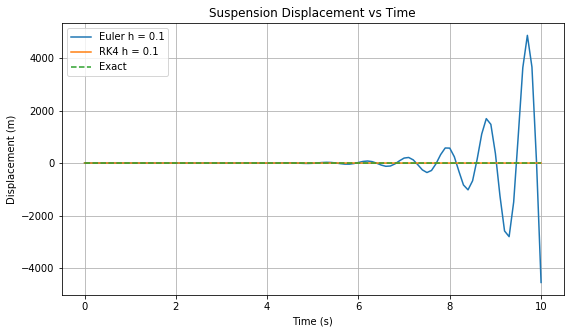

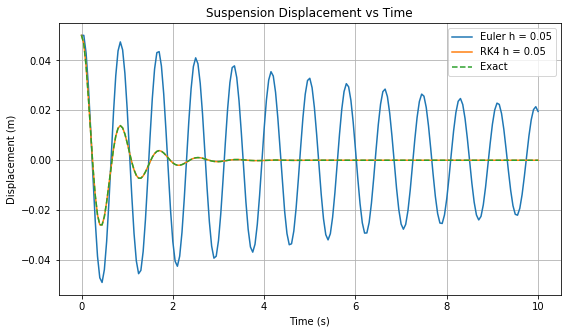

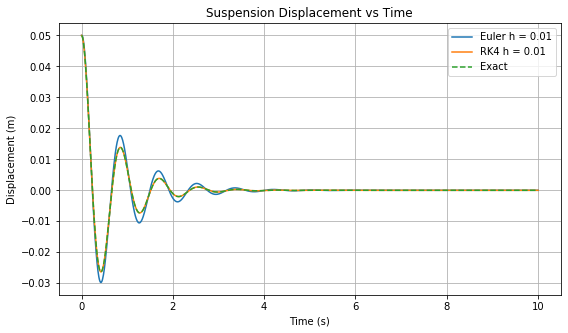

In [6]:
# Compare step sizes

step_sizes = [0.1, 0.05, 0.01]

for h in step_sizes:
    t_e, y_e = euler_forward_system(suspension_system, t0, tf, h, initial_state)
    t_r, y_r = rk4_system(suspension_system, t0, tf, h, initial_state)
    
    plt.figure(figsize=(9, 5))
    plt.plot(t_e, y_e[:, 0], label="Euler h = " + str(h))
    plt.plot(t_r, y_r[:, 0], label="RK4 h = " + str(h))
    plt.plot(t_e, exact_solution(t_e), "--", label="Exact")
    plt.xlabel("Time (s)")
    plt.ylabel("Displacement (m)")
    plt.title("Suspension Displacement vs Time")
    plt.legend()
    plt.grid(True)
    plt.show()

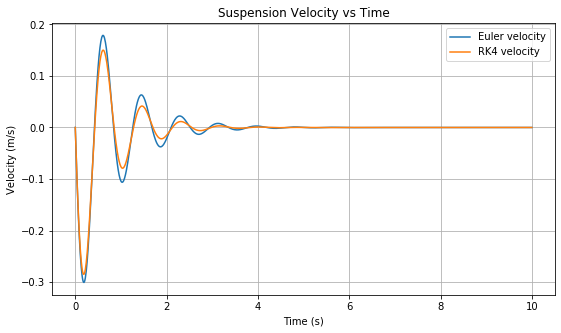

In [7]:
# Velocity comparison

h = 0.01

t_e, y_e = euler_forward_system(suspension_system, t0, tf, h, initial_state)
t_r, y_r = rk4_system(suspension_system, t0, tf, h, initial_state)

plt.figure(figsize=(9, 5))
plt.plot(t_e, y_e[:, 1], label="Euler velocity")
plt.plot(t_r, y_r[:, 1], label="RK4 velocity")
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.title("Suspension Velocity vs Time")
plt.legend()
plt.grid(True)
plt.show()

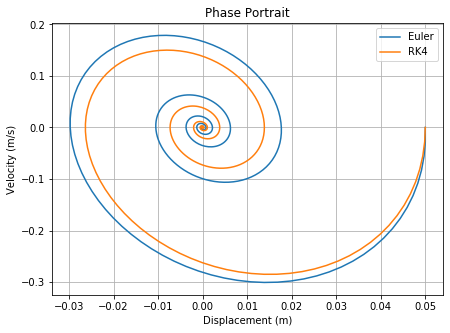

In [8]:
# Phase portrait

plt.figure(figsize=(7, 5))
plt.plot(y_e[:, 0], y_e[:, 1], label="Euler")
plt.plot(y_r[:, 0], y_r[:, 1], label="RK4")
plt.xlabel("Displacement (m)")
plt.ylabel("Velocity (m/s)")
plt.title("Phase Portrait")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# Stability Analysis

A = np.array([
    [0, 1],
    [-k/m, -c/m]
])

def euler_stability_matrix(h):
    I = np.eye(2)
    return I + h * A

def rk4_stability_matrix(h):
    I = np.eye(2)
    H = h * A
    return I + H + (H @ H)/2 + (H @ H @ H)/6 + (H @ H @ H @ H)/24

test_steps = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5]

for h in test_steps:
    euler_matrix = euler_stability_matrix(h)
    rk4_matrix = rk4_stability_matrix(h)
    
    euler_eigs = np.linalg.eigvals(euler_matrix)
    rk4_eigs = np.linalg.eigvals(rk4_matrix)
    
    print("h =", h)
    
    print("Euler eigenvalue magnitudes:", np.abs(euler_eigs))
    if np.all(np.abs(euler_eigs) <= 1):
        print("Euler: Solution is Stable")
    else:
        print("Euler: Solution may not be Entirely Stable ;)")
    
    print("RK4 eigenvalue magnitudes:", np.abs(rk4_eigs))
    if np.all(np.abs(rk4_eigs) <= 1):
        print("RK4: Solution is Stable")
    else:
        print("RK4: Solution may not be Entirely Stable ;)")
    
    print()

h = 0.01
Euler eigenvalue magnitudes: [0.987687 0.987687]
Euler: Solution is Stable
RK4 eigenvalue magnitudes: [0.9850335 0.9850335]
RK4: Solution is Stable

h = 0.05
Euler eigenvalue magnitudes: [0.99565348 0.99565348]
Euler: Solution is Stable
RK4 eigenvalue magnitudes: [0.92741435 0.92741435]
RK4: Solution is Stable

h = 0.1
Euler eigenvalue magnitudes: [1.12556489 1.12556489]
Euler: Solution may not be Entirely Stable ;)
RK4 eigenvalue magnitudes: [0.86077148 0.86077148]
RK4: Solution is Stable

h = 0.2
Euler eigenvalue magnitudes: [1.63424939 1.63424939]
Euler: Solution may not be Entirely Stable ;)
RK4 eigenvalue magnitudes: [0.72793252 0.72793252]
RK4: Solution is Stable

h = 0.3
Euler eigenvalue magnitudes: [2.28289821 2.28289821]
Euler: Solution may not be Entirely Stable ;)
RK4 eigenvalue magnitudes: [0.41518973 0.41518973]
RK4: Solution is Stable

h = 0.5
Euler eigenvalue magnitudes: [3.70192732 3.70192732]
Euler: Solution may not be Entirely Stable ;)
RK4 eigenvalue magnitu

In [10]:
# Find approximate maximum stable step size

h_values = np.linspace(0.001, 1.0, 1000)

max_euler_h = 0
max_rk4_h = 0

for h in h_values:
    euler_eigs = np.linalg.eigvals(euler_stability_matrix(h))
    rk4_eigs = np.linalg.eigvals(rk4_stability_matrix(h))
    
    if np.all(np.abs(euler_eigs) <= 1):
        max_euler_h = h
        
    if np.all(np.abs(rk4_eigs) <= 1):
        max_rk4_h = h

print("Approximate maximum stable Euler step size:", max_euler_h)
print("Approximate maximum stable RK4 step size:", max_rk4_h)

Approximate maximum stable Euler step size: 0.053000000000000005
Approximate maximum stable RK4 step size: 0.389


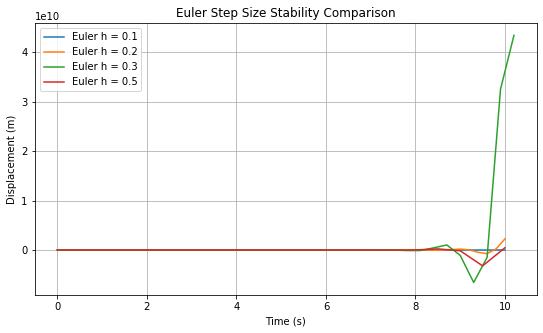

In [11]:
# Show unstable behavior

unstable_steps = [0.1, 0.2, 0.3, 0.5]

plt.figure(figsize=(9, 5))

for h in unstable_steps:
    t_e, y_e = euler_forward_system(suspension_system, t0, tf, h, initial_state)
    plt.plot(t_e, y_e[:, 0], label="Euler h = " + str(h))

plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.title("Euler Step Size Stability Comparison")
plt.legend()
plt.grid(True)
plt.show()

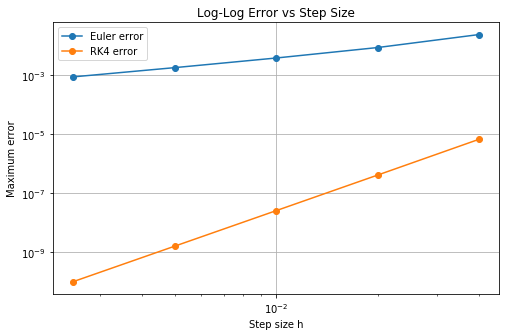

Euler errors: [0.02443865008630801, 0.00883581445562351, 0.0038947938347938995, 0.0018321840295488223, 0.0008890969072497309]
RK4 errors: [6.708071114166006e-06, 4.0678831532588167e-07, 2.5092751539806946e-08, 1.5568010734712256e-09, 9.692629684976417e-11]


In [12]:
# Error Analysis
# Use stable step sizes only for a fair convergence test

error_steps = [0.04, 0.02, 0.01, 0.005, 0.0025]

euler_errors = []
rk4_errors = []

for h in error_steps:
    t_e, y_e = euler_forward_system(suspension_system, t0, tf, h, initial_state)
    t_r, y_r = rk4_system(suspension_system, t0, tf, h, initial_state)
    
    exact_e = exact_solution(t_e)
    exact_r = exact_solution(t_r)
    
    euler_error = np.max(np.abs(y_e[:, 0] - exact_e))
    rk4_error = np.max(np.abs(y_r[:, 0] - exact_r))
    
    euler_errors.append(euler_error)
    rk4_errors.append(rk4_error)

plt.figure(figsize=(8, 5))
plt.loglog(error_steps, euler_errors, "o-", label="Euler error")
plt.loglog(error_steps, rk4_errors, "o-", label="RK4 error")
plt.xlabel("Step size h")
plt.ylabel("Maximum error")
plt.title("Log-Log Error vs Step Size")
plt.legend()
plt.grid(True)
plt.show()

print("Euler errors:", euler_errors)
print("RK4 errors:", rk4_errors)

In [13]:
# Estimate convergence slopes

euler_slope = np.polyfit(np.log(error_steps), np.log(euler_errors), 1)[0]
rk4_slope = np.polyfit(np.log(error_steps), np.log(rk4_errors), 1)[0]

print("Euler convergence slope:", euler_slope)
print("RK4 convergence slope:", rk4_slope)

Euler convergence slope: 1.1831158930424674
RK4 convergence slope: 4.01868504689292


## Part 2

In [14]:
# Parameters for stiff RC circuit

R = 100
C = 1e-9
RC = R * C

lam = 1 / RC

V0 = 0
t0 = 0
tf = 5

print("RC =", RC)
print("lambda =", lam)
print("Time scale =", RC, "seconds")
print("Stiffness ratio =", 1 / RC)

RC = 1.0000000000000001e-07
lambda = 10000000.0
Time scale = 1.0000000000000001e-07 seconds
Stiffness ratio = 10000000.0


In [15]:
# ODE: dV/dt = -lambda*V + lambda*5*sin(t)

def V_source(t):
    return 5 * np.sin(t)

def f(t, V):
    return -lam * V + lam * V_source(t)

In [16]:
# Euler Forward for scalar RC circuit

def euler_forward_rc(f, t0, tf, h, V0):
    t = np.arange(t0, tf + h, h)
    V = np.zeros(len(t))
    V[0] = V0
    
    for i in range(1, len(t)):
        V[i] = V[i-1] + h * f(t[i-1], V[i-1])
        
    return t, V

In [17]:
# Newton-Raphson solver for Backward Euler

def newton_solver(t_next, V_old, h, guess, tol=1e-6, max_iter=20):
    V_new = guess
    
    for i in range(max_iter):
        g = V_new - V_old - h * f(t_next, V_new)
        gp = 1 + h * lam
        
        V_next = V_new - g / gp
        
        if abs(V_next - V_new) < tol:
            return V_next, i + 1
        
        V_new = V_next
        
    return V_new, max_iter

In [18]:
# Euler Backward with Newton-Raphson

def euler_backward(f, t0, tf, h, V0):
    t = np.arange(t0, tf + h, h)
    V = np.zeros(len(t))
    iterations = np.zeros(len(t))
    V[0] = V0
    
    for i in range(1, len(t)):
        t_next = t[i]
        guess = V[i-1]
        V[i], iterations[i] = newton_solver(t_next, V[i-1], h, guess)
        
    return t, V, iterations

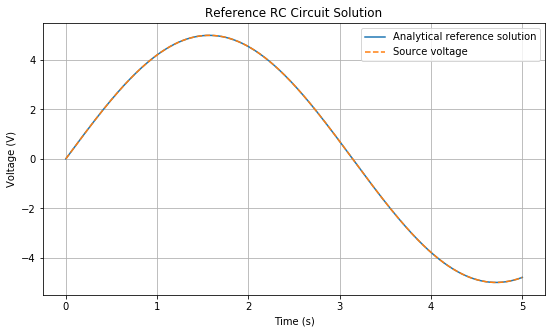

In [19]:
# Analytical reference solution for the stiff RC circuit
# This avoids using another numerical method as the "exact" comparison.

def exact_rc_solution(t):
    a = 5 * lam**2 / (lam**2 + 1)
    b = -5 * lam / (lam**2 + 1)
    c_const = V0 - b
    return a * np.sin(t) + b * np.cos(t) + c_const * np.exp(-lam * t)

t_ref = np.linspace(t0, tf, 5000)
V_ref = exact_rc_solution(t_ref)

plt.figure(figsize=(9, 5))
plt.plot(t_ref, V_ref, label="Analytical reference solution")
plt.plot(t_ref, V_source(t_ref), "--", label="Source voltage")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Reference RC Circuit Solution")
plt.legend()
plt.grid(True)
plt.show()

<ipython-input-15-d70b6e752feb>:7: RuntimeWarning: overflow encountered in double_scalars
  return -lam * V + lam * V_source(t)
<ipython-input-16-7a164cf0353d>:9: RuntimeWarning: invalid value encountered in double_scalars
  V[i] = V[i-1] + h * f(t[i-1], V[i-1])


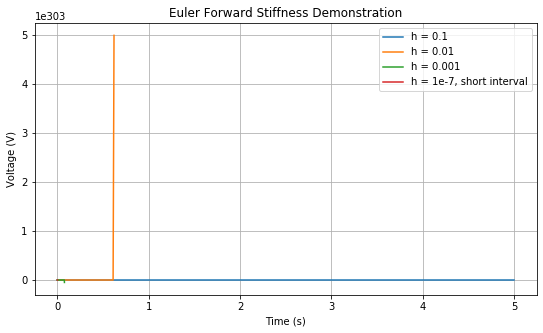

In [20]:
# Demonstrate stiffness with Euler Forward
# Use a shorter time interval for the very small stable step

forward_steps = [0.1, 0.01, 0.001]
short_stable_h = 1e-7
short_tf = 0.001

plt.figure(figsize=(9, 5))

for h in forward_steps:
    t, V = euler_forward_rc(f, t0, tf, h, V0)
    plt.plot(t, V, label="h = " + str(h))

t_small, V_small = euler_forward_rc(f, t0, short_tf, short_stable_h, V0)
plt.plot(t_small, V_small, label="h = 1e-7, short interval")

plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Euler Forward Stiffness Demonstration")
plt.legend()
plt.grid(True)
plt.show()

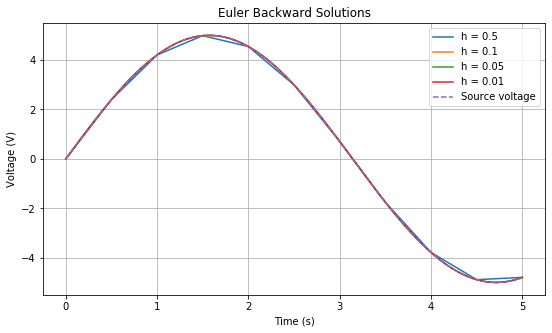

In [21]:
# Euler Backward with larger step sizes

backward_steps = [0.5, 0.1, 0.05, 0.01]

plt.figure(figsize=(9, 5))

for h in backward_steps:
    t, V, iterations = euler_backward(f, t0, tf, h, V0)
    plt.plot(t, V, label="h = " + str(h))

plt.plot(t_ref, V_source(t_ref), "--", label="Source voltage")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Euler Backward Solutions")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
# Stability comparison

def forward_stable(h):
    return abs(1 - h * lam) <= 1

def backward_stable(h):
    return abs(1 / (1 + h * lam)) <= 1

test_steps = [1e-8, 1e-7, 1e-6, 0.001, 0.01, 0.1]

for h in test_steps:
    print("h =", h)
    
    if forward_stable(h):
        print("Euler Forward: Stable")
    else:
        print("Euler Forward: Unstable")
        
    if backward_stable(h):
        print("Euler Backward: Stable")
    else:
        print("Euler Backward: Unstable")
        
    print()

h = 1e-08
Euler Forward: Stable
Euler Backward: Stable

h = 1e-07
Euler Forward: Stable
Euler Backward: Stable

h = 1e-06
Euler Forward: Unstable
Euler Backward: Stable

h = 0.001
Euler Forward: Unstable
Euler Backward: Stable

h = 0.01
Euler Forward: Unstable
Euler Backward: Stable

h = 0.1
Euler Forward: Unstable
Euler Backward: Stable



In [23]:
# Maximum stable Euler Forward step size

h_forward_max = 2 / lam

print("Maximum stable Euler Forward h =", h_forward_max)
print("Euler Backward is stable for much larger h values.")
print("Number of Euler Forward steps needed for 5 seconds:", tf / h_forward_max)

Maximum stable Euler Forward h = 2e-07
Euler Backward is stable for much larger h values.
Number of Euler Forward steps needed for 5 seconds: 25000000.0


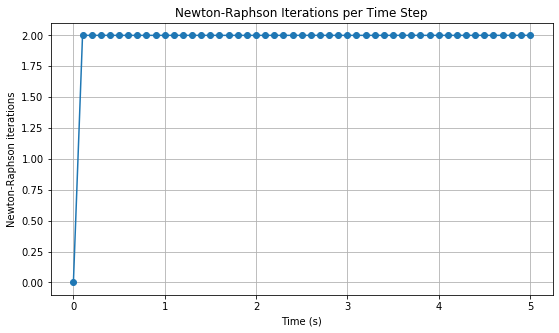

Average iterations: 2.0
Maximum iterations: 2.0


In [24]:
# Newton-Raphson iterations vs time

h = 0.1
t_b, V_b, iterations_b = euler_backward(f, t0, tf, h, V0)

plt.figure(figsize=(9, 5))
plt.plot(t_b, iterations_b, "o-")
plt.xlabel("Time (s)")
plt.ylabel("Newton-Raphson iterations")
plt.title("Newton-Raphson Iterations per Time Step")
plt.grid(True)
plt.show()

print("Average iterations:", np.mean(iterations_b[1:]))
print("Maximum iterations:", np.max(iterations_b))

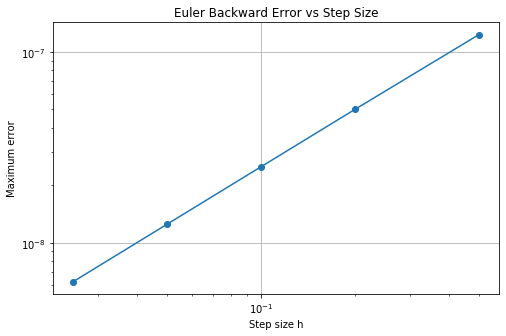

In [25]:
# Error analysis compared to analytical reference

error_steps = [0.5, 0.2, 0.1, 0.05, 0.025]
backward_errors = []

for h in error_steps:
    t, V, iterations = euler_backward(f, t0, tf, h, V0)
    V_exact = exact_rc_solution(t)
    error = np.max(np.abs(V - V_exact))
    backward_errors.append(error)

plt.figure(figsize=(8, 5))
plt.loglog(error_steps, backward_errors, "o-")
plt.xlabel("Step size h")
plt.ylabel("Maximum error")
plt.title("Euler Backward Error vs Step Size")
plt.grid(True)
plt.show()

In [26]:
# Convergence slope for Backward Euler

backward_slope = np.polyfit(np.log(error_steps), np.log(backward_errors), 1)[0]
print("Euler Backward convergence slope:", backward_slope)

Euler Backward convergence slope: 0.9957751497070046


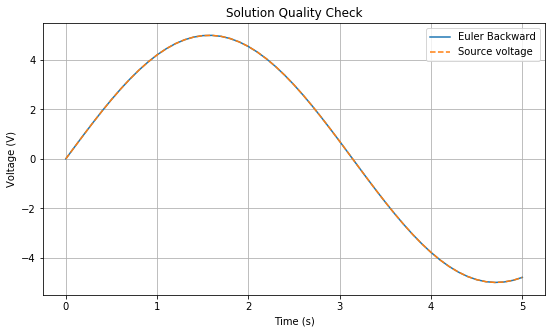

Minimum voltage: -4.999616256659184
Maximum voltage: 4.997868004814393


In [27]:
# Solution quality check

h = 0.1
t, V, iterations = euler_backward(f, t0, tf, h, V0)

plt.figure(figsize=(9, 5))
plt.plot(t, V, label="Euler Backward")
plt.plot(t, V_source(t), "--", label="Source voltage")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Solution Quality Check")
plt.legend()
plt.grid(True)
plt.show()

print("Minimum voltage:", np.min(V))
print("Maximum voltage:", np.max(V))

## Part 3

In [28]:
# Residual functions for implicit solve

def g_func(V_new, V_old, t_next, h):
    return V_new - V_old - h * f(t_next, V_new)

def g_prime_func(h):
    return 1 + h * lam


# Basic Newton-Raphson

def basic_newton(V_old, t_next, h, guess=None, tol=1e-8, max_iter=20):
    if guess is None:
        V_guess = V_old
    else:
        V_guess = guess

    for k in range(max_iter):
        g = g_func(V_guess, V_old, t_next, h)

        if abs(g) < tol:
            return V_guess, k + 1, True

        gp = g_prime_func(h)
        delta = -g / gp
        V_guess = V_guess + delta

    return V_guess, max_iter, False


# Damped Newton-Raphson with line search

def damped_newton(V_old, t_next, h, guess=None, tol=1e-8, max_iter=20, alpha_min=1e-4):
    if guess is None:
        V_guess = V_old
    else:
        V_guess = guess

    damping_count = 0
    final_alpha = 1.0
    function_evals = 0

    for k in range(max_iter):
        g = g_func(V_guess, V_old, t_next, h)
        function_evals += 1

        if abs(g) < tol:
            return V_guess, k + 1, True, final_alpha, damping_count, function_evals

        gp = g_prime_func(h)
        delta = -g / gp

        alpha = 1.0
        g_current = abs(g)

        for j in range(10):
            V_new = V_guess + alpha * delta
            g_new = abs(g_func(V_new, V_old, t_next, h))
            function_evals += 1

            if g_new < g_current:
                break

            alpha = alpha / 2
            damping_count += 1

            if alpha < alpha_min:
                return V_guess, k + 1, False, alpha, damping_count, function_evals

        final_alpha = alpha
        V_guess = V_new

    return V_guess, max_iter, False, final_alpha, damping_count, function_evals

In [29]:
# One implicit Euler step

def implicit_step(V_old, t_old, h):
    t_next = t_old + h
    V_new, iters, success, alpha, damping_count, evals = damped_newton(V_old, t_next, h)
    return V_new, iters, success, alpha, damping_count, evals


# Step-doubling error estimate

def estimate_error(V_old, t_old, h):
    V_full, it1, success1, alpha1, damp1, eval1 = implicit_step(V_old, t_old, h)

    V_half1, it2, success2, alpha2, damp2, eval2 = implicit_step(V_old, t_old, h/2)
    V_half2, it3, success3, alpha3, damp3, eval3 = implicit_step(V_half1, t_old + h/2, h/2)

    error = abs(V_half2 - V_full)
    total_iters = it1 + it2 + it3
    total_damping = damp1 + damp2 + damp3
    total_evals = eval1 + eval2 + eval3
    success = success1 and success2 and success3

    return V_full, V_half2, error, total_iters, total_damping, total_evals, success


# Adaptive step size logic

def adaptive_step(V_old, t_old, h, tol, h_min=1e-8, h_max=1.0, safety=0.9):

    V_full, V_half, err, iters, damping_count, evals, success = estimate_error(V_old, t_old, h)

    if not success:
        return V_old, h, max(h_min, h/2), False, iters, err, damping_count, evals

    if err < 1e-14:
        h_new = min(2*h, h_max)
    else:
        h_new = h * np.sqrt(tol / err)
        h_new = safety * h_new
        h_new = max(h_min, min(h_max, h_new))

    h_new = max(0.2*h, min(5.0*h, h_new))

    if err < tol:
        return V_half, h, h_new, True, iters, err, damping_count, evals
    else:
        return V_old, h, h_new, False, iters, err, damping_count, evals


# Full adaptive implicit Euler solver

def adaptive_implicit_euler(f, V0, t0, tf, h0, tol):

    t = [t0]
    V = [V0]
    h = h0

    h_history = []
    error_history = []
    accepted_history = []

    stats = {
        "accepted": 0,
        "rejected": 0,
        "nr_iters": 0,
        "damping_used": 0,
        "function_evals": 0
    }

    while t[-1] < tf:

        if t[-1] + h > tf:
            h = tf - t[-1]

        V_new, h_used, h_new, accepted, iters, err, damping_count, evals = adaptive_step(
            V[-1], t[-1], h, tol
        )

        stats["nr_iters"] += iters
        stats["damping_used"] += damping_count
        stats["function_evals"] += evals

        if accepted:
            t.append(t[-1] + h_used)
            V.append(V_new)
            h_history.append(h_used)
            error_history.append(err)
            accepted_history.append(1)
            stats["accepted"] += 1
        else:
            accepted_history.append(0)
            stats["rejected"] += 1

        h = h_new

        if h < 1e-12:
            print("Step size became too small.")
            break

    return np.array(t), np.array(V), h_history, error_history, accepted_history, stats

In [30]:
# Damping comparison
# The main RC equation is linear, so basic Newton already converges easily.
# To clearly test damping, this cell uses a nonlinear stress-test residual.

def nonlinear_g(y):
    return y**3 - y - 2

def nonlinear_g_prime(y):
    return 3*y**2 - 1


def basic_newton_nonlinear(guess, tol=1e-8, max_iter=20):
    y = guess
    residuals = []

    for k in range(max_iter):
        g = nonlinear_g(y)
        residuals.append(abs(g))

        if abs(g) < tol:
            return y, k + 1, True, residuals

        gp = nonlinear_g_prime(y)
        y = y - g / gp

    return y, max_iter, False, residuals


def damped_newton_nonlinear(guess, tol=1e-8, max_iter=20, alpha_min=1e-4):
    y = guess
    residuals = []
    damping_count = 0
    final_alpha = 1.0

    for k in range(max_iter):
        g = nonlinear_g(y)
        residuals.append(abs(g))

        if abs(g) < tol:
            return y, k + 1, True, residuals, final_alpha, damping_count

        gp = nonlinear_g_prime(y)
        delta = -g / gp

        alpha = 1.0
        g_current = abs(g)

        for j in range(20):
            y_new = y + alpha * delta
            g_new = abs(nonlinear_g(y_new))

            if g_new < g_current:
                break

            alpha = alpha / 2
            damping_count += 1

            if alpha < alpha_min:
                return y, k + 1, False, residuals, alpha, damping_count

        final_alpha = alpha
        y = y_new

    return y, max_iter, False, residuals, final_alpha, damping_count


bad_guess = 0.5

y_basic, basic_iters, basic_success, basic_res = basic_newton_nonlinear(bad_guess)
y_damped, damp_iters, damp_success, damped_res, alpha, damping_count = damped_newton_nonlinear(bad_guess)

print("Damping Stress Test with Nonlinear Residual")
print("------------------------------------------")
print("Residual: g(y) = y^3 - y - 2")
print("Initial guess:", bad_guess)
print()
print("Basic Newton:")
print("Converged:", basic_success)
print("Iterations:", basic_iters)
print("Final value:", y_basic)
print("Final residual:", basic_res[-1])
print()
print("Damped Newton:")
print("Converged:", damp_success)
print("Iterations:", damp_iters)
print("Final value:", y_damped)
print("Final residual:", damped_res[-1])
print("Final alpha:", alpha)
print("Backtracking steps:", damping_count)
print()
print("This stress test is only to show why damping is useful. The main RC problem is linear, so it usually does not need damping.")

Damping Stress Test with Nonlinear Residual
------------------------------------------
Residual: g(y) = y^3 - y - 2
Initial guess: 0.5

Basic Newton:
Converged: False
Iterations: 20
Final value: -15.442828259091932
Final residual: 12388.191546475593

Damped Newton:
Converged: True
Iterations: 7
Final value: 1.5213797068472417
Final residual: 2.5364599309796176e-10
Final alpha: 1.0
Backtracking steps: 4

This stress test is only to show why damping is useful. The main RC problem is linear, so it usually does not need damping.


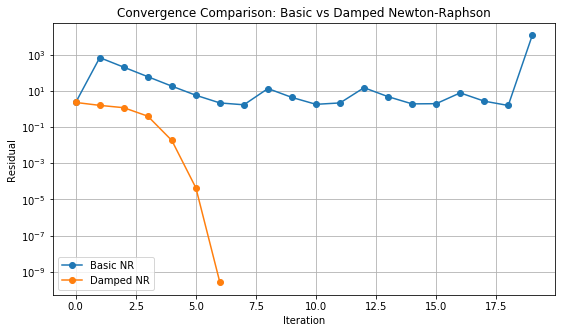

In [31]:
# Residual history comparison for the nonlinear damping stress test

plt.figure(figsize=(9,5))
plt.semilogy(basic_res, "o-", label="Basic NR")
plt.semilogy(damped_res, "o-", label="Damped NR")
plt.xlabel("Iteration")
plt.ylabel("Residual")
plt.title("Convergence Comparison: Basic vs Damped Newton-Raphson")
plt.legend()
plt.grid(True)
plt.show()

In [32]:
# Run adaptive solver

t_adapt, V_adapt, h_hist, err_hist, accept_hist, stats = adaptive_implicit_euler(
    f, V0, t0, tf, h0=0.1, tol=1e-4
)

print("Adaptive Solver Results")
print("------------------------")
print("Accepted steps:", stats["accepted"])
print("Rejected steps:", stats["rejected"])
print("Total NR iterations:", stats["nr_iters"])
print("Damping/backtracking steps:", stats["damping_used"])
print("Function evaluations:", stats["function_evals"])
print("Acceptance rate:", stats["accepted"] / (stats["accepted"] + stats["rejected"]))

Adaptive Solver Results
------------------------
Accepted steps: 7
Rejected steps: 0
Total NR iterations: 42
Damping/backtracking steps: 0
Function evaluations: 63
Acceptance rate: 1.0


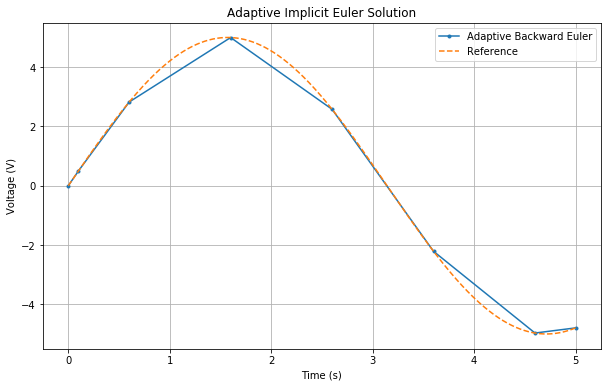

In [33]:
# Adaptive solution plot

plt.figure(figsize=(10,6))
plt.plot(t_adapt, V_adapt, "o-", markersize=3, label="Adaptive Backward Euler")
plt.plot(t_ref, V_ref, "--", label="Reference")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Adaptive Implicit Euler Solution")
plt.legend()
plt.grid(True)
plt.show()

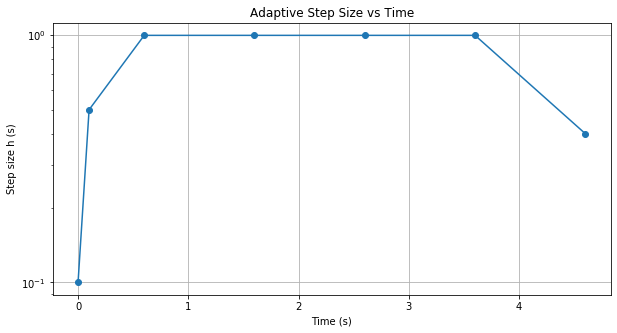

In [34]:
# Step size plot

plt.figure(figsize=(10,5))
plt.semilogy(t_adapt[:-1], h_hist, "o-")
plt.xlabel("Time (s)")
plt.ylabel("Step size h (s)")
plt.title("Adaptive Step Size vs Time")
plt.grid(True)
plt.show()

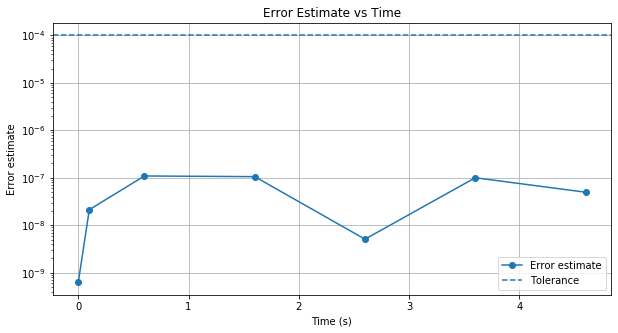

In [35]:
# Error estimate plot

plt.figure(figsize=(10,5))
plt.semilogy(t_adapt[:-1], err_hist, "o-", label="Error estimate")
plt.axhline(y=1e-4, linestyle="--", label="Tolerance")
plt.xlabel("Time (s)")
plt.ylabel("Error estimate")
plt.title("Error Estimate vs Time")
plt.legend()
plt.grid(True)
plt.show()

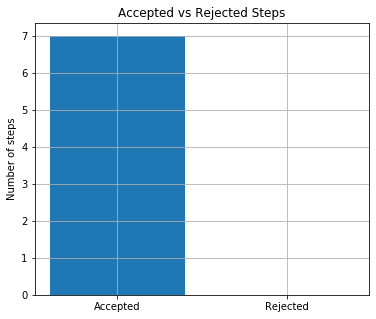

In [36]:
# Accepted vs rejected steps

labels = ["Accepted", "Rejected"]
values = [stats["accepted"], stats["rejected"]]

plt.figure(figsize=(6,5))
plt.bar(labels, values)
plt.ylabel("Number of steps")
plt.title("Accepted vs Rejected Steps")
plt.grid(True)
plt.show()

In [37]:
# Fixed vs adaptive performance comparison at a similar accuracy target

target_accuracy = max(adapt_error if "adapt_error" in globals() else 0, 1e-4)
fixed_candidates = [0.5, 0.2, 0.1, 0.05, 0.025, 0.01, 0.005]

best_fixed = None

for h_try in fixed_candidates:
    t_try, V_try, iter_try = euler_backward(f, t0, tf, h_try, V0)
    exact_try = exact_rc_solution(t_try)
    error_try = np.max(np.abs(V_try - exact_try))

    if error_try <= target_accuracy:
        best_fixed = (h_try, t_try, V_try, iter_try, error_try)
        break

if best_fixed is None:
    h_try = fixed_candidates[-1]
    t_try, V_try, iter_try = euler_backward(f, t0, tf, h_try, V0)
    exact_try = exact_rc_solution(t_try)
    error_try = np.max(np.abs(V_try - exact_try))
    best_fixed = (h_try, t_try, V_try, iter_try, error_try)

fixed_h, t_fixed, V_fixed, fixed_iterations, fixed_error = best_fixed

V_exact_adapt = exact_rc_solution(t_adapt)
adapt_error = np.max(np.abs(V_adapt - V_exact_adapt))

fixed_steps = len(t_fixed) - 1
fixed_nr_iters = int(np.sum(fixed_iterations[1:]))
fixed_function_evals = fixed_nr_iters

print("Performance Comparison")
print("--------------------------------------------------------------------")
print(f"{'Method':<20}{'Steps':<12}{'NR Iters':<12}{'Func Evals':<15}{'Max Error':<15}")
print("--------------------------------------------------------------------")
print(f"{'Fixed h=' + str(fixed_h):<20}{fixed_steps:<12}{fixed_nr_iters:<12}{fixed_function_evals:<15}{fixed_error:<15.6e}")
print(f"{'Adaptive':<20}{stats['accepted']:<12}{stats['nr_iters']:<12}{stats['function_evals']:<15}{adapt_error:<15.6e}")
print()
print("This compares the adaptive solver against a fixed step chosen to reach about the same accuracy level.")

Performance Comparison
--------------------------------------------------------------------
Method              Steps       NR Iters    Func Evals     Max Error      
--------------------------------------------------------------------
Fixed h=0.5         10          20          20             1.232252e-07   
Adaptive            7           42          63             1.229660e-07   

This compares the adaptive solver against a fixed step chosen to reach about the same accuracy level.


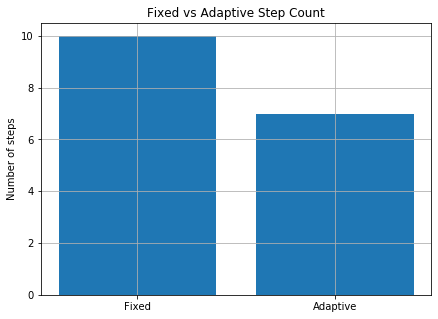

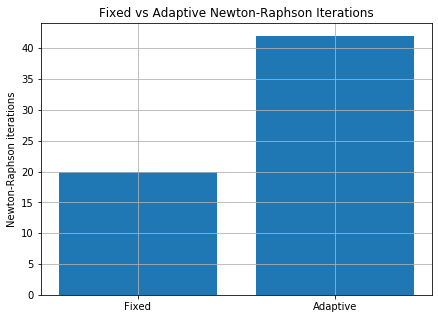

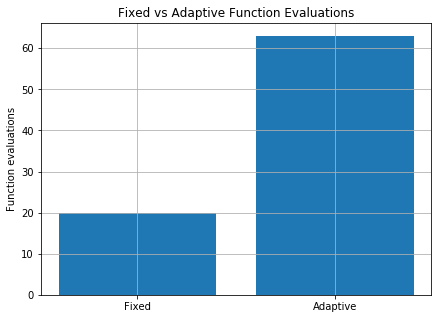

In [38]:
# Performance bar charts

methods = ["Fixed", "Adaptive"]
steps = [fixed_steps, stats["accepted"]]
iters = [fixed_nr_iters, stats["nr_iters"]]
evals = [fixed_function_evals, stats["function_evals"]]

plt.figure(figsize=(7,5))
plt.bar(methods, steps)
plt.ylabel("Number of steps")
plt.title("Fixed vs Adaptive Step Count")
plt.grid(True)
plt.show()

plt.figure(figsize=(7,5))
plt.bar(methods, iters)
plt.ylabel("Newton-Raphson iterations")
plt.title("Fixed vs Adaptive Newton-Raphson Iterations")
plt.grid(True)
plt.show()

plt.figure(figsize=(7,5))
plt.bar(methods, evals)
plt.ylabel("Function evaluations")
plt.title("Fixed vs Adaptive Function Evaluations")
plt.grid(True)
plt.show()

Large Initial Step Test
-----------------------
Accepted steps: 5
Rejected steps: 0
Total NR iterations: 30
Acceptance rate: 1.0


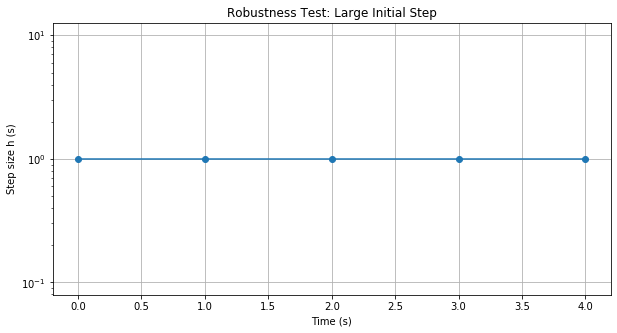

In [39]:
# Robustness test 1: large initial step

t_large, V_large, h_large, err_large, accept_large, stats_large = adaptive_implicit_euler(
    f, V0, t0, tf, h0=1.0, tol=1e-4
)

print("Large Initial Step Test")
print("-----------------------")
print("Accepted steps:", stats_large["accepted"])
print("Rejected steps:", stats_large["rejected"])
print("Total NR iterations:", stats_large["nr_iters"])
print("Acceptance rate:", stats_large["accepted"] / (stats_large["accepted"] + stats_large["rejected"]))

plt.figure(figsize=(10,5))
plt.semilogy(t_large[:-1], h_large, "o-")
plt.xlabel("Time (s)")
plt.ylabel("Step size h (s)")
plt.title("Robustness Test: Large Initial Step")
plt.grid(True)
plt.show()

Tight Tolerance Test
--------------------
Accepted steps: 52
Rejected steps: 10
Total NR iterations: 372
Acceptance rate: 0.8387096774193549


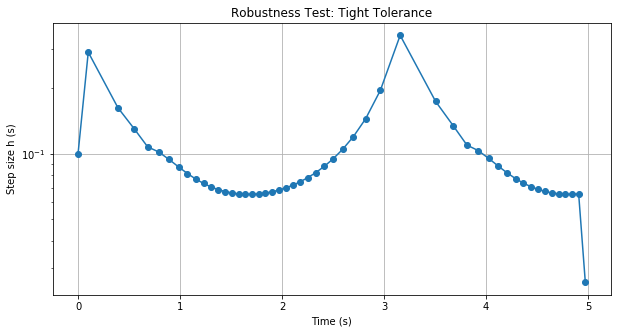

In [40]:
# Robustness test 2: tight tolerance

t_tight, V_tight, h_tight, err_tight, accept_tight, stats_tight = adaptive_implicit_euler(
    f, V0, t0, tf, h0=0.1, tol=1e-8
)

print("Tight Tolerance Test")
print("--------------------")
print("Accepted steps:", stats_tight["accepted"])
print("Rejected steps:", stats_tight["rejected"])
print("Total NR iterations:", stats_tight["nr_iters"])
print("Acceptance rate:", stats_tight["accepted"] / (stats_tight["accepted"] + stats_tight["rejected"]))

plt.figure(figsize=(10,5))
plt.semilogy(t_tight[:-1], h_tight, "o-")
plt.xlabel("Time (s)")
plt.ylabel("Step size h (s)")
plt.title("Robustness Test: Tight Tolerance")
plt.grid(True)
plt.show()

# Final Project Markdown Explanations

## Part 1 System and State Explanation

For Part 1, I modeled a simplified quarter-car suspension system. The goal was to use a second-order ODE so I could compare Euler Forward and RK4 on a system with position and velocity.

The original suspension equation is:

m*y'' + c*y' + k*y = 0

This is second-order because it contains y''. Since Euler Forward and RK4 solve first-order systems, I rewrote it using a state vector.

State vector:

state = [y1, y2]

where:

y1 = displacement  
y2 = velocity

So:

y1' = y2

and:

y2' = -(c/m)*y2 - (k/m)*y1

This is why the code returns two values: the derivative of displacement and the derivative of velocity.

The model is a simplified free-response model after a bump. The initial displacement is 0.05 m and the initial velocity is 0 m/s.

Sources used for parameters:
- 2011 Toyota 4Runner curb weight: Edmunds lists curb weight as 4,675 lb. Source: https://www.edmunds.com/toyota/4runner/2011/features-specs/
- Passenger car suspension natural frequency: Vibrationdata gives passenger car fundamental frequency as 1 to 1.5 Hz. Source: https://www.vibrationdata.com/tutorials_alt/bump.pdf
- Damping ratio: Kaz Technologies notes a passenger car typically has damping ratio around 0.2. Source: https://www.kaztechnologies.com/wp-content/uploads/A-Guide-To-Your-Dampers-Chapter-from-FSAE-Book-by-Jim-Kasprzak-Updated.pdf

I used these values to estimate quarter-car mass, spring stiffness, and damping coefficient.

## Part 1 Results

Euler Forward and RK4 both solve the same suspension system, but they behave differently as step size changes.

Euler Forward is simpler because it uses only the slope at the current point. RK4 is more accurate because it uses four slope estimates per step.

In the convergence test, I only used stable step sizes. This matters because unstable step sizes do not measure normal error behavior; they measure numerical blow-up. With stable step sizes, Euler behaves like a lower-order method and RK4 gives much smaller error.

## Part 2 System Selection: Stiff RC Circuit

For Parts 2 and 3, I switched from the suspension model to a stiff RC circuit. Part 1 was mainly about comparing Euler Forward and RK4 on a second-order system. Parts 2 and 3 focus on stiff scalar ODEs, so the RC circuit is a better fit.

The governing ODE is:

dV/dt = -lambda*V + lambda*Vs(t)

where:

lambda = 1 / (RC)

For this problem:

R = 100 ohms  
C = 10^-9 F

So:

RC = 10^-7 seconds

and:

lambda = 10^7

The source voltage is:

Vs(t) = 5sin(t)

So the final ODE is:

dV/dt = -10^7 V + 5*10^7 sin(t)

This system is stiff because the circuit responds on a time scale of 10^-7 seconds, while the input signal changes over seconds. The fast and slow time scales are very different.

The stiffness ratio is approximately 10^7 because the slow input changes over about 1 second while the fast RC time scale is 10^-7 seconds.

This is why Euler Forward needs an extremely small step size to stay stable.

## Backward Euler and Newton-Raphson Setup

For a scalar ODE:

dV/dt = f(t,V)

Backward Euler is:

V_(n+1) = V_n + h*f(t_(n+1), V_(n+1))

This is implicit because V_(n+1) appears on both sides. To solve it, I defined:

g(V_(n+1)) = V_(n+1) - V_n - h*f(t_(n+1), V_(n+1))

For the RC circuit:

f(t,V) = -lambda*V + lambda*Vs(t)

So:

g(V_(n+1)) = V_(n+1) - V_n - h*(-lambda*V_(n+1) + lambda*Vs(t_(n+1)))

The derivative is:

g'(V_(n+1)) = 1 + h*lambda

This derivative is constant, so Newton-Raphson is simple for this problem.

## Part 2 Results

Euler Forward became unstable for larger step sizes. This happened because lambda = 10^7, so the updates became extremely large.

The stability condition for Euler Forward is:

abs(1 - h*lambda) <= 1

This means the maximum stable step size is:

h <= 2 / lambda

For this problem:

h <= 2*10^-7

That is extremely small, so Euler Forward is not practical over the full simulation time.

Euler Backward was much better for this stiff problem. It stayed stable with much larger step sizes and did not blow up like Euler Forward.

## Part 3: Damped Newton-Raphson

Basic Newton-Raphson always takes the full update step. This can be a problem if the step size is large, the initial guess is bad, or the equation is nonlinear.

To make Newton-Raphson more reliable, I added damping. The damped update is:

V_new = V_old - alpha * g(V_old) / g'(V_old)

where alpha is between 0 and 1.

The method starts with alpha = 1. If the residual does not decrease, alpha is cut in half until the update improves the solution.

For the main RC circuit, the implicit equation is linear, so Newton-Raphson usually converges without needing damping. To still verify the damping logic, I added a nonlinear stress test using g(y) = y^3 - y - 2. In that test, basic Newton can fail from a poor initial guess, while damped Newton reduces the residual and converges. This shows the purpose of damping even though the RC circuit itself is simple for Newton-Raphson.

## Adaptive Step Size

Using one fixed step size is not always efficient. A small step size is accurate but slow. A large step size is faster but may be inaccurate.

To fix this, I used adaptive step sizing with step-doubling.

The idea is:

1. Take one full step of size h
2. Take two half steps of size h/2
3. Compare the results

The error estimate is:

error = abs(V_half - V_full)

If the error is below the tolerance, the step is accepted. If the error is too large, the step is rejected and repeated with a smaller step size.

The new step size is based on:

h_new = h * sqrt(tol / error)

This lets the solver automatically use small steps when needed and larger steps when the solution is smooth.

## Adaptive Solver Results

The adaptive solution followed the reference solution well. The time points were not evenly spaced because the solver changed the step size automatically.

The step size plot showed that the solver adjusted h throughout the simulation. The error plot showed that the estimated error stayed controlled near the tolerance.

Rejected steps are not failures. They are part of the method. A rejected step means the solver detected that the error was too large and tried again with a smaller step.

## Performance Analysis

I compared the fixed step Backward Euler method with the adaptive Backward Euler method.

The fixed step method is simple because it uses the same h for the entire simulation. The downside is that it can waste computation when the solution is smooth.

The adaptive method does more work per attempted step because it uses step-doubling. However, it can also use larger steps when possible, so it avoids unnecessary calculations.

The main comparison is accuracy versus cost. In this notebook, the fixed step is chosen to reach about the same accuracy target as the adaptive method. The adaptive method is still useful because it controls error automatically and avoids using the same tiny step everywhere.

## Robustness Testing

I tested the solver with a large initial step size and with a tighter tolerance.

The large initial step test showed that the adaptive solver could recover when the first step size was too aggressive. It reduced the step size when needed.

The tight tolerance test showed that the solver could automatically take smaller steps to improve accuracy.

In both cases, the solver handled the situation without breaking.

## Final Conclusion

In this project, I first used Euler Forward and RK4 on a suspension model to understand basic numerical time stepping. Then I switched to a stiff RC circuit for Parts 2 and 3 because stiff systems better demonstrate the need for implicit methods.

The RC circuit is stiff because the circuit time constant is RC = 10^-7 seconds, while the input voltage changes over seconds. This creates a large time scale separation of about 10^7.

Euler Forward was not practical because it required an extremely small step size to stay stable. Backward Euler fixed this stability problem because it is much better suited for stiff ODEs.

Newton-Raphson was used to solve the implicit equation at each step. Damping made Newton-Raphson more robust by preventing bad updates from increasing the residual, even though this linear RC circuit usually does not require backtracking.

Adaptive step sizing improved the solver by changing h automatically. It used small steps when needed and larger steps when the solution was smooth.

Overall:

- Euler Forward showed the stiffness problem.
- Backward Euler fixed the stability issue.
- Damping improved robustness.
- Adaptive step size improved efficiency.

Together, these methods created a more stable and reliable ODE solver. The function evaluation count includes the residual evaluations inside Newton-Raphson and the extra residual checks used by the damping line search.
